In [284]:
import io
import os
import json
import pandas as pd
import numpy as np
from datetime import datetime as dt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.api as sm
import plotly.express as px
from IPython.display import HTML
from IPython.display import Image
import warnings
warnings.filterwarnings('ignore')

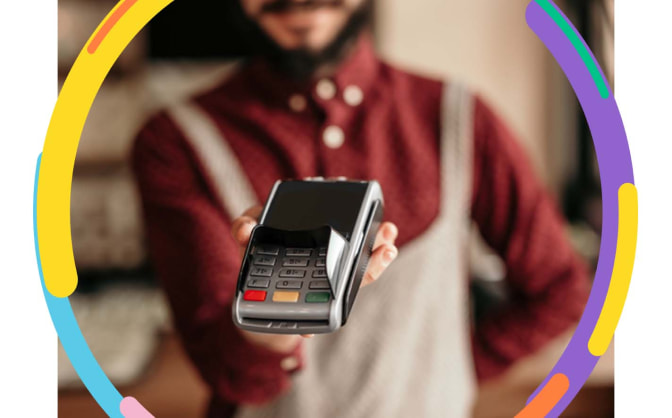

In [ ]:
Image(filename = "img/datafono_fisico.jpg", width=1500, height=500)


# Introducción

In [150]:
df = pd.read_excel('main_data/evolucion_vinculacion_y_uso_adquirencia_1_a_1.xlsx', sheet_name='Sheet1', converters={'fecha_ymd2': pd.Timestamp})
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   periodo                     55 non-null     int64         
 1   fecha_ymd2                  55 non-null     datetime64[ns]
 2   num_vinc_new                55 non-null     int64         
 3   num_vinc_new_cumsum_ym      55 non-null     int64         
 4   num_vinc_new_cumsum         55 non-null     int64         
 5   num_vinc_old                55 non-null     int64         
 6   num_vinc_all                55 non-null     int64         
 7   num_vinc_new_uso_cumsum_ym  55 non-null     int64         
 8   num_vinc_old_uso_cumsum_ym  55 non-null     int64         
 9   num_vinc_all_uso_cumsum_ym  55 non-null     int64         
 10  num_vinc_new_prop_uso       55 non-null     float64       
 11  num_vinc_old_prop_uso       55 non-null     float64       
 

In [3]:
df

,periodo,fecha_ymd2,num_vinc_new,num_vinc_new_cumsum_ym,num_vinc_new_cumsum,num_vinc_old,num_vinc_all,num_vinc_new_uso_cumsum_ym,num_vinc_old_uso_cumsum_ym,num_vinc_all_uso_cumsum_ym,num_vinc_new_prop_uso,num_vinc_old_prop_uso,num_vinc_all_prop_uso
0,202607,2026-07-01,3812,23778,205509,447611,471385,12093,109345,121439,0.5086,0.2443,0.2576
1,202606,2026-06-01,3107,19966,201697,447619,467583,10280,108755,119036,0.5149,0.2430,0.2546
2,202605,2026-05-01,3364,16859,198590,448057,464916,8447,108073,116521,0.5010,0.2412,0.2506
3,202604,2026-04-01,3739,13495,195226,448056,461551,6523,107059,113583,0.4834,0.2389,0.2461
4,202603,2026-03-01,3887,9756,191487,448074,457831,4602,105678,110281,0.4717,0.2358,0.2409
5,202602,2026-02-01,3200,5869,187600,448099,453969,2617,103470,106088,0.4459,0.2309,0.2337
6,202601,2026-01-01,2669,2669,184400,448103,450772,1004,98960,99964,0.3762,0.2208,0.2218
7,202512,2025-12-01,3412,38305,181731,409803,448104,24455,113080,137535,0.6384,0.2759,0.3069
8,202511,2025-11-01,3284,34893,178319,409832,444725,22119,112697,134816,0.6339,0.2750,0.3031
9,202510,2025-10-01,3759,31609,175035,409896,441505,20079,112384,132463,0.6352,0.2742,0.3000


# Vinculaciones

In [5]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot3, df_plot2])
fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución Número de códigos únicos vinculados adquirencia 1 a 1 viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados adquirencia 1 a 1"
            ))
)
fig.add_annotation(x='2025-06-01', y=370000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2025-12-01', y=448104,
            text="448.104",
            showarrow=True,
            arrowhead=1)
fig.show()

In [6]:
df_plot = pd.concat([df_plot1])
fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución Número de códigos únicos vinculados adquirencia 1 a 1 nuevos",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados adquirencia 1 a 1"
            ))
)
fig.add_annotation(x='2025-06-01', y=40000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

# Uso

In [7]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old_uso_cumsum_ym']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot2, df_plot3])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de códigos únicos vinculados adquirencia 1 a 1 recibiendo al menos 1 transacción [año acumulado] viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados adquirencia 1 a 1"
            ))
)
fig.add_annotation(x='2025-06-01', y=140000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=142097,
#             text="142.097",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=103274,
#             text="103.274",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=38823,
#             text="38.823",
#             showarrow=True,
#             arrowhead=1)
fig.show()

In [8]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old_uso_cumsum_ym']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot1])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de códigos únicos vinculados adquirencia 1 a 1 recibiendo al menos 1 transacción [año acumulado] nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados adquirencia 1 a 1"
            ))
)
fig.add_annotation(x='2025-06-01', y=30000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=142097,
#             text="142.097",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=103274,
#             text="103.274",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=38823,
#             text="38.823",
#             showarrow=True,
#             arrowhead=1)
fig.show()

# Proporción uso

In [9]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_prop_uso']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old_prop_uso']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all_prop_uso']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot1[:35], df_plot2[:35], df_plot3[:35]])
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución proporción de códigos únicos vinculados adquirencia 1 a 1 realizando al menos 1 transacción [año acumulado] por nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Proporción de códigos únicos vinculados adquirencia 1 a 1"
            ))
)
fig.add_annotation(x='2025-06-01', y=0.48,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=0.3347,
#             text="0,3347",
#             showarrow=False,
#             yshift=10)
# fig.add_annotation(x='2025-11-01', y=0.319,
#             text="0,319",
#             showarrow=False,
#             yshift=10)
# fig.add_annotation(x='2025-11-01', y=0.3852,
#             text="0,3852",
#             showarrow=False,
#             yshift=10)
fig.show()

# Cifras en perspectiva histórica, metas y proyecciones

In [10]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old_uso_cumsum_ym']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

# df_plot = pd.concat([df_plot1[:35], df_plot2[:35], df_plot3[:35]])
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución códigos únicos vinculados adquirencia 1 a 1 recibiendo al menos 1 transacción [año acumulado] nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados adquirencia 1 a 1"
            ))
)
fig.add_annotation(x='2025-06-01', y=70000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2026-03-01', y=110281,
            text="110.281",
            showarrow=False,
            yshift=10)
fig.add_annotation(x='2024-12-01', y=150475,
            text="<b>150.475</b><br>Base 2024",
            yshift=10,
            font=dict(
            family="Courier New, monospace",
            size=20,
            color="#E60505"
            ))
fig.add_annotation(x='2025-12-01', y=137535,
            text="<b>137.535</b><br>Base 2025",
            yshift=10,
            font=dict(
            family="Courier New, monospace",
            size=20,
            color="#E60505"
            ))
fig.add_annotation(x='2026-03-01', y=105678,
            text="105.678",
            showarrow=False,
            yshift=-19)
fig.add_annotation(x='2026-03-01', y=4602,
            text="4.602",
            showarrow=True,
            arrowhead=1)
fig.show()

# Proyecciones

No se hace proyección con un modelo para crearla sobre las imagenes cuando se haga la presentación. Es una forma de presentar que deseo explorar, realizar la proyección con la herramienta de lapiz que tienen las herramientas de presentación.

En el futuro se puede crear proyección con modelo heurístico o modelo estadístico.

## Vinculaciones

In [4]:
# Crear periodo de tiempo
meta = 58442
index_date = pd.date_range(start='2026-01-01', end='2026-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = meta/12
df_periodo_2['valor'] = df_periodo_2['valor'].cumsum()
df_periodo_2['tipo_valor'] = 'metal_proyectada'
df_data = df[['fecha_ymd2', 'num_vinc_new_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot

,fecha,valor,tipo_valor,periodo_2
0,2026-07-01,23778.000000,real,NaN
1,2026-06-01,19966.000000,real,NaN
2,2026-05-01,16859.000000,real,NaN
3,2026-04-01,13495.000000,real,NaN
4,2026-03-01,9756.000000,real,NaN
...,...,...,...,...
62,2026-08-01,38961.333333,metal_proyectada,1.0
63,2026-09-01,43831.500000,metal_proyectada,1.0
64,2026-10-01,48701.666667,metal_proyectada,1.0
65,2026-11-01,53571.833333,metal_proyectada,1.0


In [59]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución vinculación mensual códigos únicos nuevos, y meta proyectada<br>Adquirencia 1 a 1<br>Acumulado año corrido",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos nuevos vinculados<br>acumulados año corrido<br>adquirencia 1 a 1"
            ))
)

fig.update_yaxes(visible=False)
fig.add_annotation(x='2025-06-01', y=45000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2026-12-01', y=58452,
            text="Meta proyectada<br><b>58.442</b> códigos únicos nuevos vinculados<br>acumulados en diciembre 2026",
            showarrow=False,
            xanchor='right')
fig.add_annotation(x='2026-07-01', y=34091,
            text="Meta proyectada<br><b>34.091</b> códigos únicos nuevos vinculados<br>acumulados hasta julio 2026",
            showarrow=False,
            xanchor='left',
            xshift=3,
            yshift=25)
fig.add_annotation(x='2026-07-01', y=23778,
            text="Dato real<br><b>23.778</b> códigos únicos nuevos vinculados<br>acumulados hasta julio 2026<br><b>30% por debajo de la meta proyectada</b>",
            showarrow=False,
            xanchor='left',
            xshift=3)


fig.show()

## Uso

### Viejos

In [74]:
# Crear periodo de tiempo
index_date = pd.date_range(start='2026-01-01', end='2026-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = 0
df_periodo_2['valor'][0] = 98960
# df_periodo_2['valor'] = df_periodo_2['meta_lineal_1'].cumsum()
df_periodo_2 = df_periodo_2[['fecha', 'valor']]
df_periodo_2['tipo_valor'] = 'meta_proyectada'


# Crecimiento en 2026 para lograr objetivo replicando el crecimiento mensual de 2025 partiendo del valor real de enero de 2026
df_data_2025 = df_data[(df_data['fecha'] >= pd.to_datetime('2025-01-01') ) & (df_data['fecha'] <= pd.to_datetime('2025-12-01'))].sort_values('fecha')
crecimiento_2025 = df_data_2025.valor.diff()[1:].reset_index(drop=True).div(df_data_2025.valor[:-1].reset_index(drop=True)).round(4)
crecimiento_2025.index = range(1, 12)
df_periodo_2['crecimiento_para_lograr_objetivo'] = crecimiento_2025 # Para repartir los 33.956 que hacen falta para lograr 139.916 en diciembre 2026
df_periodo_2['crecimiento_para_lograr_objetivo'][0] = 0
df_periodo_2['crecimiento_para_lograr_objetivo'] = df_periodo_2.crecimiento_para_lograr_objetivo.div(df_periodo_2.crecimiento_para_lograr_objetivo.sum())


list_meta_2026 = []
for enu, (valor, crecimiento_objetivo) in enumerate(zip(df_periodo_2['valor'], df_periodo_2['crecimiento_para_lograr_objetivo'])):
    if enu == 0:
        list_meta_2026.append(98960)
    else:
        list_meta_2026.append(round((list_meta_2026[-1] + 32284 * (crecimiento_objetivo)), 0))
df_periodo_2['valor'] = list_meta_2026


df_data = df[['fecha_ymd2', 'num_vinc_old_uso_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot



,fecha,valor,tipo_valor,crecimiento_para_lograr_objetivo
0,2026-07-01,109345.0,real,NaN
1,2026-06-01,108755.0,real,NaN
2,2026-05-01,108073.0,real,NaN
3,2026-04-01,107059.0,real,NaN
4,2026-03-01,105678.0,real,NaN
...,...,...,...,...
62,2026-08-01,123104.0,meta_proyectada,0.064445
63,2026-09-01,125256.0,meta_proyectada,0.066646
64,2026-10-01,127387.0,meta_proyectada,0.066017
65,2026-11-01,129194.0,meta_proyectada,0.055957


In [79]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': 'Evolución mensual códigos únicos viejos con uso, y meta proyectada<br>Adquirencia 1 a 1<br>Acumulado año corrido<br>Uso: Al menos 1 transacción en el año corrido',
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos viejos con uso<br>acumulados año corrido<br>adquirencia 1 a 1"
            ))
)
fig.update_yaxes(visible=False)
fig.add_annotation(x='2025-06-01', y=125000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2026-12-01', y=131244,
            text="Meta proyectada<br><b>131.244</b> códigos únicos viejos con uso<br>acumulados en diciembre 2026",
            showarrow=False,
            xanchor='auto')
fig.add_annotation(x='2026-07-01', y=121023,
            text="Meta proyectada<br><b>121.023</b> códigos únicos viejos con uso<br>acumulados en julio 2026",
            showarrow=False,
            xanchor='left',
            xshift=3)
fig.add_annotation(x='2026-07-01', y=109345,
            text="Dato real<br><b>109.345</b> códigos únicos viejos con uso<br>acumulados hasta julio 2026.<br><b>10% por debajo de la meta proyectada</b>",
            showarrow=False,
            xanchor='left',
            xshift=3,
            yshift=45)
fig.show()

In [73]:
21658+109586

131244

In [431]:
10270/115948

0.08857418842929589

### Nuevos

In [81]:
# Crear periodo de tiempo
meta = 49363
index_date = pd.date_range(start='2026-01-01', end='2026-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = meta/12
df_periodo_2['valor'] = df_periodo_2['valor'].cumsum()
df_periodo_2['tipo_valor'] = 'metal_proyectada'
df_data = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot

,fecha,valor,tipo_valor,periodo_2
0,2026-07-01,12093.000000,real,NaN
1,2026-06-01,10280.000000,real,NaN
2,2026-05-01,8447.000000,real,NaN
3,2026-04-01,6523.000000,real,NaN
4,2026-03-01,4602.000000,real,NaN
...,...,...,...,...
62,2026-08-01,32908.666667,metal_proyectada,1.0
63,2026-09-01,37022.250000,metal_proyectada,1.0
64,2026-10-01,41135.833333,metal_proyectada,1.0
65,2026-11-01,45249.416667,metal_proyectada,1.0


In [85]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': 'Evolución mensual códigos únicos nuevos con uso, y meta proyectada<br>Adquirencia 1 a 1<br>Acumulado año corrido<br>Uso: Al menos 1 transacción en el año corrido',
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos nuevos con uso<br>acumulados año corrido<br>adquirencia 1 a 1"
            ))
)
fig.update_yaxes(visible=False)
fig.add_annotation(x='2025-06-01', y=32000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2026-12-01', y=49363,
            text="Meta proyectada<br><b>49.363</b> códigos únicos nuevos con uso<br>acumulados en diciembre 2026",
            showarrow=False,
            xanchor='right')
fig.add_annotation(x='2026-07-01', y=28795,
            text="Meta proyectada<br><b>28.795</b> códigos únicos nuevos con uso<br>acumulados en julio 2026",
            showarrow=False,
            xanchor='left',
            xshift=3)
fig.add_annotation(x='2026-07-01', y=12093,
            text="Dato real<br><b>12.093</b> códigos únicos nuevos con uso<br>acumulados hasta julio 2026.<br><b>58% por debajo de la meta proyectada</b>",
            showarrow=False,
            xanchor='left',
            xshift=3,
            yshift=25)

fig.show()

### Todos

In [8]:
# Crear periodo de tiempo
index_date = pd.date_range(start='2026-01-01', end='2026-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = 0
df_periodo_2['valor'][0] = 99964
# df_periodo_2['valor'] = df_periodo_2['meta_lineal_1'].cumsum()
df_periodo_2 = df_periodo_2[['fecha', 'valor']]
df_periodo_2['tipo_valor'] = 'meta_proyectada'


# Crecimiento en 2026 para lograr objetivo replicando el crecimiento mensual de 2025 partiendo del valor real de enero de 2026
df_data_2025 = df_data[(df_data['fecha'] >= pd.to_datetime('2025-01-01') ) & (df_data['fecha'] <= pd.to_datetime('2025-12-01'))].sort_values('fecha')
crecimiento_2025 = df_data_2025.valor.diff()[1:].reset_index(drop=True).div(df_data_2025.valor[:-1].reset_index(drop=True)).round(4)
crecimiento_2025.index = range(1, 12)
df_periodo_2['crecimiento_para_lograr_objetivo'] = crecimiento_2025 # Para repartir los 76.977 que hacen falta para lograr 139.916 en diciembre 2026
df_periodo_2['crecimiento_para_lograr_objetivo'][0] = 0
df_periodo_2['crecimiento_para_lograr_objetivo'] = df_periodo_2.crecimiento_para_lograr_objetivo.div(df_periodo_2.crecimiento_para_lograr_objetivo.sum())


list_meta_2026 = []
for enu, (valor, crecimiento_objetivo) in enumerate(zip(df_periodo_2['valor'], df_periodo_2['crecimiento_para_lograr_objetivo'])):
    if enu == 0:
        list_meta_2026.append(99964)
    else:
        list_meta_2026.append(round((list_meta_2026[-1] + 80643 * (crecimiento_objetivo)), 0))
df_periodo_2['valor'] = list_meta_2026


df_data = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot



,fecha,valor,tipo_valor,crecimiento_para_lograr_objetivo
0,2026-07-01,121439.0,real,NaN
1,2026-06-01,119036.0,real,NaN
2,2026-05-01,116521.0,real,NaN
3,2026-04-01,113583.0,real,NaN
4,2026-03-01,110281.0,real,NaN
...,...,...,...,...
62,2026-08-01,160273.0,meta_proyectada,0.064445
63,2026-09-01,165648.0,meta_proyectada,0.066646
64,2026-10-01,170972.0,meta_proyectada,0.066017
65,2026-11-01,175485.0,meta_proyectada,0.055957


In [9]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': 'Evolución mensual códigos únicos totales con uso, y meta proyectada<br>Adquirencia 1 a 1<br>Acumulado año corrido<br>Uso: Al menos 1 transacción en el año corrido',
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos totales con uso<br>acumulados año corrido<br>adquirencia 1 a 1"
            ))
)
fig.update_yaxes(visible=False)
fig.add_annotation(x='2025-06-01', y=150000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2026-12-01', y=180608,
            text="Meta proyectada<br><b>180.608</b> códigos únicos totales con uso<br>acumulados en diciembre 2026",
            showarrow=False,
            xanchor='auto')
fig.add_annotation(x='2026-07-01', y=155076,
            text="Meta proyectada<br><b>155.076</b> códigos únicos totales con uso<br>acumulados en julio 2026",
            showarrow=False,
            xanchor='left',
            xshift=3)
fig.add_annotation(x='2026-07-01', y=121439,
            text="Dato real<br><b>121.439</b> códigos únicos totales con uso<br>acumulados hasta julio 2026.<br><b>22% por debajo de la meta proyectada</b>",
            showarrow=False,
            xanchor='left',
            xshift=3)

fig.show()

In [10]:
# Guardar imagen plotly como png
fig.write_image("img/meta_proyectada_uso_all.png", scale=2)

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [356]:
125083-110281

14802

In [357]:
14802/125083

0.11833742395049687

# Contribución

## Vinculaciones

In [5]:
df

,periodo,fecha_ymd2,num_vinc_new,num_vinc_new_cumsum_ym,num_vinc_new_cumsum,num_vinc_old,num_vinc_all,num_vinc_new_uso_cumsum_ym,num_vinc_old_uso_cumsum_ym,num_vinc_all_uso_cumsum_ym,num_vinc_new_prop_uso,num_vinc_old_prop_uso,num_vinc_all_prop_uso
0,202607,2026-07-01,3812,23778,205509,447611,471385,12093,109345,121439,0.5086,0.2443,0.2576
1,202606,2026-06-01,3107,19966,201697,447619,467583,10280,108755,119036,0.5149,0.2430,0.2546
2,202605,2026-05-01,3364,16859,198590,448057,464916,8447,108073,116521,0.5010,0.2412,0.2506
3,202604,2026-04-01,3739,13495,195226,448056,461551,6523,107059,113583,0.4834,0.2389,0.2461
4,202603,2026-03-01,3887,9756,191487,448074,457831,4602,105678,110281,0.4717,0.2358,0.2409
5,202602,2026-02-01,3200,5869,187600,448099,453969,2617,103470,106088,0.4459,0.2309,0.2337
6,202601,2026-01-01,2669,2669,184400,448103,450772,1004,98960,99964,0.3762,0.2208,0.2218
7,202512,2025-12-01,3412,38305,181731,409803,448104,24455,113080,137535,0.6384,0.2759,0.3069
8,202511,2025-11-01,3284,34893,178319,409832,444725,22119,112697,134816,0.6339,0.2750,0.3031
9,202510,2025-10-01,3759,31609,175035,409896,441505,20079,112384,132463,0.6352,0.2742,0.3000


In [93]:

df_plot3 = df[['fecha_ymd2', 'num_vinc_new']]
df_plot3.columns = ['fecha', 'cantidad_clientes']

df_plot = df_plot3

fig = px.line(df_plot, x="fecha", y="cantidad_clientes",markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de vinculaciones por clientes nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-06-01', y=3000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.show()

# Ajustar modelos

In [318]:
# Selección variable
df_model = df[['fecha_ymd2', 'num_vinc_new_cumsum_ym']]
df_model.columns = ['fecha', 'num_vinc']
df_model.sort_values(by='fecha', inplace=True)

# Agregar variables
# Tendencia
df_model['tendencia'] = [i + 1 for i in range(len(df_model))]

# Tendencia cuadrática
df_model['tendencia_cuadratica'] = df_model['tendencia'] ** 2

# Tendencia cúbica
df_model['tendencia_cubica'] = df_model['tendencia'] ** 3

# Inicio campana
# index_date = pd.to_datetime(['2025-06-01', '2025-07-01'])
index_date = pd.date_range(start='2025-06-01', end='2026-07-31', freq='MS')
df_campana= pd.Series(['1' for v in range(len(index_date))], index=index_date).reset_index()
df_campana.columns = ['fecha', 'campana']
df_model = df_model.merge(df_campana, how='left', on='fecha').fillna('0')

# Meses
df_model['meses'] = df_model.fecha.apply(lambda x: x.month)

# Year
df_model['year'] = df_model.fecha.apply(lambda x: x.year)

# Meses dummies
df_meses_dummies = pd.get_dummies(df_model['meses'], dtype=float, drop_first=True, prefix='mes')
df_model = pd.concat([df_model, df_meses_dummies], axis=1)

# Años dummies
df_years_dummies = pd.get_dummies(df_model['year'], dtype=float, drop_first=True, prefix='year')
df_model = pd.concat([df_model, df_years_dummies], axis=1)
df_model

,fecha,num_vinc,tendencia,tendencia_cuadratica,tendencia_cubica,campana,meses,year,mes_2,mes_3,...,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,year_2023,year_2024,year_2025,year_2026
0,2022-01-01,2756,1,1,1,0,1,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-02-01,6346,2,4,8,0,2,2022,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-03-01,11127,3,9,27,0,3,2022,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-04-01,15050,4,16,64,0,4,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-05-01,19497,5,25,125,0,5,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2022-06-01,23697,6,36,216,0,6,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2022-07-01,27788,7,49,343,0,7,2022,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2022-08-01,32611,8,64,512,0,8,2022,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2022-09-01,37558,9,81,729,0,9,2022,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2022-10-01,42447,10,100,1000,0,10,2022,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Modelo lineal

In [319]:
mod = smf.ols(formula="num_vinc ~ tendencia", data=df_model)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               num_vinc   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.7742
Date:                Mon, 24 Aug 2026   Prob (F-statistic):              0.383
Time:                        02:32:50   Log-Likelihood:                -602.31
No. Observations:                  55   AIC:                             1209.
Df Residuals:                      53   BIC:                             1213.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.554e+04   3842.737      6.647      0.0

In [320]:
df_plot1 = df_model[['fecha', 'num_vinc']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[['fecha']]
df_plot2['num_vinc'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_vinc", color='vble_dep', markers=True)
fig.show()

## Modelo cuadrático

In [321]:
# Modelo cuadrático
mod = smf.ols(formula="num_vinc ~ tendencia + I(tendencia ** 2) + I(tendencia ** 3) + year_2023 + year_2024 + year_2025 + mes_2 + mes_3 + mes_4 + mes_5 + mes_6 + mes_7 + mes_8 + mes_9 + mes_10 + mes_11 + mes_12",
              data=df_model[(df_model['fecha'] >= '2022-01-01') & (df_model['fecha'] <= '2025-03-01')])
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               num_vinc   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     1472.
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           1.48e-29
Time:                        02:32:50   Log-Likelihood:                -294.50
No. Observations:                  39   AIC:                             623.0
Df Residuals:                      22   BIC:                             651.3
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          2089.9896    525.86

In [322]:
df_plot1 = df_model[['fecha', 'num_vinc']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[['fecha']]
df_plot2['num_vinc'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_vinc", color='vble_dep', markers=True)
fig.show()


## Obtener contrafactual

In [323]:
# Modelo seleccionado
df_model_i1 = df_model[(df_model['fecha'] >= '2022-01-01') & (df_model['fecha'] <= '2025-03-01')]
mod = smf.ols(formula="num_vinc ~ tendencia + I(tendencia ** 2) + I(tendencia ** 3) + year + mes_2 + mes_3 + mes_4 + mes_5 + mes_6 + mes_7 + mes_8 + mes_9 + mes_10 + mes_11 + mes_12",
              data=df_model_i1)
res = mod.fit()

In [324]:
df_model['num_vinc'].var(), df_model['num_vinc'].mean()

(196727479.73400667, 22602.454545454544)

In [325]:
df_model['num_vinc'].var() > df_model['num_vinc'].mean()

True

In [334]:
df_model.columns

Index(['fecha', 'num_vinc', 'tendencia', 'tendencia_cuadratica',
       'tendencia_cubica', 'campana', 'meses', 'year', 'mes_2', 'mes_3',
       'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10',
       'mes_11', 'mes_12', 'year_2023', 'year_2024', 'year_2025', 'year_2026'],
      dtype='object')

In [379]:
# Modelo seleccionado
variables_independientes = ['tendencia', 'tendencia_cuadratica', 'year', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12']
df_model_i1 = df_model[(df_model['fecha'] >= '2022-01-01') & (df_model['fecha'] <= '2025-03-01')]
X = sm.add_constant(df_model_i1[variables_independientes])
y = df_model_i1['num_vinc']
mod = sm.GLM(y, X, family=sm.families.NegativeBinomial())
res = mod.fit()

In [380]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               num_vinc   No. Observations:                   39
Model:                            GLM   Df Residuals:                       25
Model Family:        NegativeBinomial   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -420.60
Date:                Mon, 24 Aug 2026   Deviance:                     0.042571
Time:                        02:39:15   Pearson chi2:                   0.0424
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4448
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0064      0.001      4.267      0.000       0.003       0.009
tendencia                0.0280      0.062      0.455      0.649      -0.093       0.149
tendencia_cuadratica    -0.0009      0.001     -0.612      0.541      -0.004       0.002
year                     0.0039      0.000     12.010      0.000       0.003       0.005
mes_2                    0.8074      0.707      1.141      0.254      -0.579       2.194
mes_3                    1.2946      0.708      1.829      0.067      -0.093       2.682
mes_4                    1.5650      0.772      2.027      0.043       0.052       3.078
mes_5                    1.8095      0.773      2.342      0.019       0.295       3.324
mes_6                    1.9943      0.773      2.579      0.010       0.478       3.510
mes_7                    2.1631      0.774      2.795      0.005       0.646       3.680
mes_8                    2.3109      0.774      2.984      0.003       0.793       3.829
mes_9                    2.4523      0.775      3.166      0.002       0.934       3.970
mes_10                   2.5744      0.774      3.324      0.001       1.056       4.092
mes_11                   2.6901      0.774      3.474      0.001       1.173       4.208
mes_12                   2.7826      0.774      3.595      0.000       1.266       4.300
========================================================================================
"""

In [381]:
df_model_new_data = df_model[df_model['fecha'] >= '2025-04-01']
df_model_new_data

,fecha,num_vinc,tendencia,tendencia_cuadratica,tendencia_cubica,campana,meses,year,mes_2,mes_3,...,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,year_2023,year_2024,year_2025,year_2026
39,2025-04-01,11159,40,1600,64000,0,4,2025,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
40,2025-05-01,14390,41,1681,68921,0,5,2025,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
41,2025-06-01,17541,42,1764,74088,1,6,2025,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
42,2025-07-01,21240,43,1849,79507,1,7,2025,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
43,2025-08-01,24210,44,1936,85184,1,8,2025,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
44,2025-09-01,27850,45,2025,91125,1,9,2025,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
45,2025-10-01,31609,46,2116,97336,1,10,2025,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
46,2025-11-01,34893,47,2209,103823,1,11,2025,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
47,2025-12-01,38305,48,2304,110592,1,12,2025,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
48,2026-01-01,2669,49,2401,117649,1,1,2026,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [382]:
X_new = sm.add_constant(df_model_new_data[variables_independientes])
res.predict(X_new).reset_index(drop=True)

0      9469.135006
1     11548.349646
2     13244.150836
3     14919.044576
4     16428.292978
5     17939.909795
6     19183.299568
7     20343.768085
8     21040.259151
9      1230.136314
10     2591.027928
11     3955.208408
12     4851.278799
13     5788.188453
14     6494.170240
15     7156.775190
dtype: float64

In [383]:
df_plot1 = df_model[['fecha', 'num_vinc']]
df_plot1['Valor'] = 'Real'
df_plot1


,fecha,num_vinc,Valor
0,2022-01-01,2756,Real
1,2022-02-01,6346,Real
2,2022-03-01,11127,Real
3,2022-04-01,15050,Real
4,2022-05-01,19497,Real
5,2022-06-01,23697,Real
6,2022-07-01,27788,Real
7,2022-08-01,32611,Real
8,2022-09-01,37558,Real
9,2022-10-01,42447,Real


In [384]:
df_plot2 = df_model_new_data[['fecha', 'num_vinc']].reset_index(drop=True)
df_plot2['num_vinc'] = res.predict(X_new).reset_index(drop=True)
df_plot2['Valor'] = 'Contrafactual'
df_plot2

,fecha,num_vinc,Valor
0,2025-04-01,9469.135006,Contrafactual
1,2025-05-01,11548.349646,Contrafactual
2,2025-06-01,13244.150836,Contrafactual
3,2025-07-01,14919.044576,Contrafactual
4,2025-08-01,16428.292978,Contrafactual
5,2025-09-01,17939.909795,Contrafactual
6,2025-10-01,19183.299568,Contrafactual
7,2025-11-01,20343.768085,Contrafactual
8,2025-12-01,21040.259151,Contrafactual
9,2026-01-01,1230.136314,Contrafactual


In [385]:
df_plot3 = df_model_i1[['fecha']]
df_plot3['num_vinc'] = res.fittedvalues
df_plot3['Valor'] = 'Ajustado'
df_plot3

,fecha,num_vinc,Valor
0,2022-01-01,2830.230539,Ajustado
1,2022-02-01,6507.788294,Ajustado
2,2022-03-01,10844.847351,Ajustado
3,2022-04-01,14521.218284,Ajustado
4,2022-05-01,18913.949768,Ajustado
5,2022-06-01,23166.263228,Ajustado
6,2022-07-01,27870.351219,Ajustado
7,2022-08-01,32776.564526,Ajustado
8,2022-09-01,38226.171889,Ajustado
9,2022-10-01,43654.942827,Ajustado


In [389]:
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])


fig = px.line(df_plot, x="fecha", y="num_vinc", color='Valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Contrafactual número de vinculaciones",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha base"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
# fig.add_annotation(x='2025-11-01', y=408348,
#             text="408.348",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=363875,
#             text="363.875",
#             showarrow=True,
#             arrowhead=1)
fig.add_annotation(x='2025-06-01', y=40000,
            text="Inicio estrategia 5X",
            showarrow=False)
fig.show()

In [392]:
df_plot_bar = df_plot[df_plot['fecha'] == '2026-07-01']
df_plot_bar

,fecha,num_vinc,Valor
54,2026-07-01,23778.00000,Real
15,2026-07-01,7156.77519,Contrafactual


In [393]:
fig = px.bar(df_plot_bar, x='Valor', y='num_vinc', color='Valor', template='simple_white', text_auto=True)
fig.update_layout(
    title={
        'text': "Contrafactual número de vinculaciones",
        'xanchor': 'left',
        'yanchor': 'top'},
    yaxis=dict(
            title=dict(
                text="Número de clientes vinculados"
            ))
)
fig.show()

In [398]:
df_resumen_wide = df_plot.pivot(index='fecha', columns='Valor', values='num_vinc')
df_resumen_wide = df_resumen_wide.reset_index()
df_resumen_wide['contribucion_banco'] = df_resumen_wide['Real'] - df_resumen_wide['Contrafactual']
df_resumen_wide['efecto_prop_banco'] = df_resumen_wide['contribucion_banco'] / df_resumen_wide['Real']
df_resumen_wide

Valor,fecha,Ajustado,Contrafactual,Real,contribucion_banco,efecto_prop_banco
0,2022-01-01,2830.230539,NaN,2756.0,NaN,NaN
1,2022-02-01,6507.788294,NaN,6346.0,NaN,NaN
2,2022-03-01,10844.847351,NaN,11127.0,NaN,NaN
3,2022-04-01,14521.218284,NaN,15050.0,NaN,NaN
4,2022-05-01,18913.949768,NaN,19497.0,NaN,NaN
5,2022-06-01,23166.263228,NaN,23697.0,NaN,NaN
6,2022-07-01,27870.351219,NaN,27788.0,NaN,NaN
7,2022-08-01,32776.564526,NaN,32611.0,NaN,NaN
8,2022-09-01,38226.171889,NaN,37558.0,NaN,NaN
9,2022-10-01,43654.942827,NaN,42447.0,NaN,NaN


In [399]:
df_resumen_wide.to_excel('main_data/contrafactual_num_vinculaciones.xlsx', index=False)

## Uso

In [ ]:
df.columns

Index(['Unnamed: 0', 'fecha_ym', 'fecha_ym2', 'num_vinc_new',
       'num_vinc_new_cumsum_ym', 'num_vinc_new_uso_cumsum_ym',
       'num_vinc_new_prop_uso', 'num_vinc_old', 'num_vinc_old_uso_cumsum_ym',
       'num_vinc_old_prop_uso', 'num_vinc_cumsum',
       'num_vinc_all_uso_cumsum_ym', 'num_vinc_all_prop_uso'],
      dtype='object')

In [ ]:

df_plot3 = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']

df_plot = df_plot3

fig = px.line(df_plot, x="fecha", y="cantidad_clientes",markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución uso clientes nuevos",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-06-01', y=40000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=37253,
            text="37.253",
            showarrow=True,
            arrowhead=1)
fig.show()

In [ ]:
# Selección variable
df_model = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_model.columns = ['fecha', 'num_uso']

# Agregar variables
# Tendencia
df_model['tendencia'] = [i + 1 for i in range(len(df_model))]

# Inicio campana
# index_date = pd.to_datetime(['2025-06-01', '2025-07-01'])
index_date = pd.date_range(start='2025-06-01', end='2025-11-30', freq='MS')
df_campana= pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_campana.columns = ['fecha', 'campana']
df_model = df_model.merge(df_campana, how='left', on='fecha').fillna(0)

# Meses
df_model['meses'] = df_model.fecha.apply(lambda x: x.month)

# Year
df_model['year'] = df_model.fecha.apply(lambda x: x.year)

# Meses dummies
df_meses_dummies = pd.get_dummies(df_model['meses'], dtype=float, drop_first=True, prefix='mes')
df_model = pd.concat([df_model, df_meses_dummies], axis=1)
df_model

,fecha,num_uso,tendencia,campana,meses,year,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12
0,2022-01-01,1778,1,0.0,1,2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-02-01,4978,2,0.0,2,2022,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-03-01,9245,3,0.0,3,2022,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-04-01,12985,4,0.0,4,2022,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-05-01,16995,5,0.0,5,2022,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2022-06-01,21596,6,0.0,6,2022,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2022-07-01,25640,7,0.0,7,2022,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,2022-08-01,30401,8,0.0,8,2022,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,2022-09-01,35168,9,0.0,9,2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9,2022-10-01,39844,10,0.0,10,2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Ajustar modelos

In [ ]:
mod = smf.ols(formula="num_uso ~ tendencia", data=df_model[0:41])
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.022
Method:                 Least Squares   F-statistic:                    0.1386
Date:                Wed, 17 Dec 2025   Prob (F-statistic):              0.712
Time:                        10:40:05   Log-Likelihood:                -449.00
No. Observations:                  41   AIC:                             902.0
Df Residuals:                      39   BIC:                             905.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    2.21e+04   4501.337      4.909      0.0

In [ ]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

In [ ]:
mod = smf.ols(formula="num_uso ~ tendencia + year", data=df_model[0:41])
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     958.3
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           3.06e-33
Time:                        10:40:57   Log-Likelihood:                -368.30
No. Observations:                  41   AIC:                             742.6
Df Residuals:                      38   BIC:                             747.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   9.589e+07   2.19e+06     43.710      0.0

In [ ]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

In [ ]:
mod = smf.ols(formula="num_uso ~ tendencia + year + meses", data=df_model[0:41])
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     958.3
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           3.06e-33
Time:                        10:43:23   Log-Likelihood:                -368.30
No. Observations:                  41   AIC:                             742.6
Df Residuals:                      38   BIC:                             747.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1692      0.004     43.601      0.0

In [ ]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

In [ ]:
mod = smf.ols(formula="num_uso ~ tendencia + meses", data=df_model[0:41])
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     958.3
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           3.06e-33
Time:                        10:45:05   Log-Likelihood:                -368.30
No. Observations:                  41   AIC:                             742.6
Df Residuals:                      38   BIC:                             747.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -111.5452    814.858     -0.137      0.8

In [ ]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

In [ ]:
mod = smf.ols(formula="num_uso ~ tendencia + mes_2 + mes_3 + mes_4 + mes_5 + mes_6 + mes_7 + mes_8 + mes_9 + mes_10 + mes_11 + mes_12", data=df_model[0:41])
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     129.8
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           3.06e-21
Time:                        10:52:26   Log-Likelihood:                -366.32
No. Observations:                  41   AIC:                             758.6
Df Residuals:                      28   BIC:                             780.9
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4891.6207   1245.999      3.926      0.0

In [ ]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

In [ ]:
df_model_i1 = df_model[12:41]
df_model_i1['tendencia'] = [i + 1 for i in range(len(df_model_i1))]
mod = smf.ols(formula="num_uso ~ tendencia + year", data=df_model_i1)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     770.7
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           7.19e-24
Time:                        10:57:19   Log-Likelihood:                -256.46
No. Observations:                  29   AIC:                             518.9
Df Residuals:                      26   BIC:                             523.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   9.106e+07   2.32e+06     39.244      0.0

In [ ]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

In [ ]:
df_model_i1 = df_model[24:41]
df_model_i1['tendencia'] = [i + 1 for i in range(len(df_model_i1))]
mod = smf.ols(formula="num_uso ~ tendencia + year", data=df_model_i1)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                num_uso   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     3400.
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           1.55e-19
Time:                        11:06:31   Log-Likelihood:                -130.09
No. Observations:                  17   AIC:                             266.2
Df Residuals:                      14   BIC:                             268.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   8.112e+07   9.87e+05     82.147      0.0

In [ ]:
df_plot1 = df_model[:41][['fecha', 'num_uso']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[:41][['fecha']]
df_plot2['num_uso'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_uso", color='vble_dep', markers=True)
fig.show()

# Obtener contrafactual

In [ ]:
# Modelo seleccionado
df_model_i1 = df_model[24:41]
df_model_i1['tendencia'] = [i + 1 for i in range(len(df_model_i1))]
mod = smf.ols(formula="num_uso ~ tendencia + year", data=df_model_i1)
res = mod.fit()

In [ ]:
df_model_i1

,fecha,num_uso,tendencia,campana,meses,year,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12
24,2024-01-01,2221,1,0.0,1,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25,2024-02-01,5779,2,0.0,2,2024,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,2024-03-01,9282,3,0.0,3,2024,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27,2024-04-01,12131,4,0.0,4,2024,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28,2024-05-01,15160,5,0.0,5,2024,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29,2024-06-01,17724,6,0.0,6,2024,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
30,2024-07-01,20987,7,0.0,7,2024,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
31,2024-08-01,24050,8,0.0,8,2024,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
32,2024-09-01,27744,9,0.0,9,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
33,2024-10-01,31092,10,0.0,10,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
dict_new_data = {'tendencia': [18,19,20,21,22,23],
                 'year': [2025 for i in range(6)]}
df_model_new_data = pd.DataFrame(dict_new_data)
df_model_new_data

,tendencia,year
0,18,2025
1,19,2025
2,20,2025
3,21,2025
4,22,2025
5,23,2025


In [ ]:
df_model_new_data = pd.concat([df_model_i1[['tendencia', 'year']], df_model_new_data])
df_model_new_data = df_model_new_data.reset_index(drop=True)
df_model_new_data

,tendencia,year
0,1,2024
1,2,2024
2,3,2024
3,4,2024
4,5,2024
5,6,2024
6,7,2024
7,8,2024
8,9,2024
9,10,2024


In [ ]:
res.fittedvalues

24     2540.983660
25     5691.441176
26     8841.898693
27    11992.356209
28    15142.813726
29    18293.271242
30    21443.728758
31    24594.186275
32    27744.643791
33    30895.101307
34    34045.558824
35    37196.016340
36      268.284967
37     3418.742484
38     6569.200000
39     9719.657516
40    12870.115033
dtype: float64

In [ ]:
pred = res.get_prediction(df_model_new_data)
df_pred = pred.summary_frame(alpha=0.05)
df_pred

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,2540.983660,297.609886,1902.673938,3179.293382,1178.205179,3903.762141
1,5691.441176,260.717448,5132.257866,6250.624487,4363.882567,7018.999786
2,8841.898693,226.925411,8355.192093,9328.605293,7543.203501,10140.593885
3,11992.356209,197.828987,11568.055232,12416.657186,10715.736765,13268.975654
4,15142.813726,175.775668,14765.812414,15519.815037,13881.126016,16404.501435
5,18293.271242,163.638241,17942.302121,18644.240362,17039.116064,19547.426420
6,21443.728758,163.638241,21092.759638,21794.697878,20189.573580,22697.883936
7,24594.186275,175.775667,24217.184963,24971.187586,23332.498565,25855.873984
8,27744.643791,197.828987,27320.342814,28168.944768,26468.024346,29021.263235
9,30895.101307,226.925411,30408.394707,31381.807907,29596.406115,32193.796499


In [ ]:
df_model_i1

,fecha,num_uso,tendencia,campana,meses,year,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12
24,2024-01-01,2221,1,0.0,1,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25,2024-02-01,5779,2,0.0,2,2024,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,2024-03-01,9282,3,0.0,3,2024,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27,2024-04-01,12131,4,0.0,4,2024,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28,2024-05-01,15160,5,0.0,5,2024,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29,2024-06-01,17724,6,0.0,6,2024,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
30,2024-07-01,20987,7,0.0,7,2024,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
31,2024-08-01,24050,8,0.0,8,2024,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
32,2024-09-01,27744,9,0.0,9,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
33,2024-10-01,31092,10,0.0,10,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
df_plot1 = df_model[24:][['fecha', 'num_uso']]
df_plot1['Valor'] = 'Real'
df_plot1

,fecha,num_uso,Valor
24,2024-01-01,2221,Real
25,2024-02-01,5779,Real
26,2024-03-01,9282,Real
27,2024-04-01,12131,Real
28,2024-05-01,15160,Real
29,2024-06-01,17724,Real
30,2024-07-01,20987,Real
31,2024-08-01,24050,Real
32,2024-09-01,27744,Real
33,2024-10-01,31092,Real


In [ ]:
df_plot2 = df_model[['fecha']][-6:].reset_index(drop=True)
df_plot2['num_uso'] = df_pred['mean'][-6:].reset_index(drop=True)
df_plot2['Valor'] = 'Contrafactual'
df_plot2

,fecha,num_uso,Valor
0,2025-06-01,16020.572549,Contrafactual
1,2025-07-01,19171.030065,Contrafactual
2,2025-08-01,22321.487582,Contrafactual
3,2025-09-01,25471.945098,Contrafactual
4,2025-10-01,28622.402614,Contrafactual
5,2025-11-01,31772.860131,Contrafactual


In [ ]:
df_plot3 = df_model_i1[['fecha']].reset_index(drop=True)
df_plot3['num_uso'] = df_pred['mean'][:-6]
df_plot3['Valor'] = 'Ajustado'
df_plot3

,fecha,num_uso,Valor
0,2024-01-01,2540.983660,Ajustado
1,2024-02-01,5691.441176,Ajustado
2,2024-03-01,8841.898693,Ajustado
3,2024-04-01,11992.356209,Ajustado
4,2024-05-01,15142.813726,Ajustado
5,2024-06-01,18293.271242,Ajustado
6,2024-07-01,21443.728758,Ajustado
7,2024-08-01,24594.186275,Ajustado
8,2024-09-01,27744.643791,Ajustado
9,2024-10-01,30895.101307,Ajustado


In [ ]:
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])
df_plot

,fecha,num_uso,Valor
24,2024-01-01,2221.000000,Real
25,2024-02-01,5779.000000,Real
26,2024-03-01,9282.000000,Real
27,2024-04-01,12131.000000,Real
28,2024-05-01,15160.000000,Real
29,2024-06-01,17724.000000,Real
30,2024-07-01,20987.000000,Real
31,2024-08-01,24050.000000,Real
32,2024-09-01,27744.000000,Real
33,2024-10-01,31092.000000,Real


In [ ]:
fig = px.line(df_plot, x="fecha", y="num_uso", color='Valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Contrafactual número de clientes con uso",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-11-01', y=37253,
            text="37.253",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-11-01', y=31772,
            text="31.772",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-06-01', y=30000,
            text="Inicio estrategia 5X",
            showarrow=False)
fig.show()

In [ ]:
df_plot_bar = df_plot[df_plot['fecha'] == '2025-11-01']
df_plot_bar['num_uso'] = df_plot_bar.num_uso.round(0)
df_plot_bar



,fecha,num_uso,Valor
46,2025-11-01,37253.0,Real
5,2025-11-01,31773.0,Contrafactual


In [ ]:
fig = px.bar(df_plot_bar, x='Valor', y='num_uso', color='Valor', template='simple_white', text_auto=True)
fig.update_layout(
    title={
        'text': "Contrafactual número de clientes con uso",
        'xanchor': 'left',
        'yanchor': 'top'},
    yaxis=dict(
            title=dict(
                text="Número de clientes con uso"
            ))
)
fig.show()



In [ ]:
df_plot

,fecha,num_uso,Valor
24,2024-01-01,2221.000000,Real
25,2024-02-01,5779.000000,Real
26,2024-03-01,9282.000000,Real
27,2024-04-01,12131.000000,Real
28,2024-05-01,15160.000000,Real
29,2024-06-01,17724.000000,Real
30,2024-07-01,20987.000000,Real
31,2024-08-01,24050.000000,Real
32,2024-09-01,27744.000000,Real
33,2024-10-01,31092.000000,Real


In [ ]:
df_resumen_wide = df_plot.pivot(index='fecha', columns='Valor', values='num_uso')
df_resumen_wide = df_resumen_wide.reset_index()
df_resumen_wide['contribucion_banco'] = df_resumen_wide['Real'] - df_resumen_wide['Contrafactual']
df_resumen_wide['efecto_prop_banco'] = df_resumen_wide['contribucion_banco'] / df_resumen_wide['Contrafactual']
df_resumen_wide



Valor,fecha,Ajustado,Contrafactual,Real,contribucion_banco,efecto_prop_banco
0,2024-01-01,2540.983660,NaN,2221.0,NaN,NaN
1,2024-02-01,5691.441176,NaN,5779.0,NaN,NaN
2,2024-03-01,8841.898693,NaN,9282.0,NaN,NaN
3,2024-04-01,11992.356209,NaN,12131.0,NaN,NaN
4,2024-05-01,15142.813726,NaN,15160.0,NaN,NaN
5,2024-06-01,18293.271242,NaN,17724.0,NaN,NaN
6,2024-07-01,21443.728758,NaN,20987.0,NaN,NaN
7,2024-08-01,24594.186275,NaN,24050.0,NaN,NaN
8,2024-09-01,27744.643791,NaN,27744.0,NaN,NaN
9,2024-10-01,30895.101307,NaN,31092.0,NaN,NaN


In [ ]:
df_resumen_wide.to_excel('main_data/contrafactual_num_clientes_con_uso.xlsx', index=False)